In [23]:
import glob
import numpy as np
import matplotlib.pyplot as plt

In [24]:
files = glob.glob('/home/ybadoux/AMUSE/hermite_hists/*.npy')
files.sort()
files

['/home/ybadoux/AMUSE/hermite_hists/nbounds_rmin4.45_rmax13.35.npy',
 '/home/ybadoux/AMUSE/hermite_hists/nbounds_rmin7.26_rmax12.03.npy',
 '/home/ybadoux/AMUSE/hermite_hists/nbounds_rmin7.59_rmax10.99.npy',
 '/home/ybadoux/AMUSE/hermite_hists/nbounds_rmin8.03_rmax11.11.npy',
 '/home/ybadoux/AMUSE/hermite_hists/times_rmin4.45_rmax13.35.npy',
 '/home/ybadoux/AMUSE/hermite_hists/times_rmin7.26_rmax12.03.npy',
 '/home/ybadoux/AMUSE/hermite_hists/times_rmin7.59_rmax10.99.npy',
 '/home/ybadoux/AMUSE/hermite_hists/times_rmin8.03_rmax11.11.npy']

4.45 13.35
7.26 12.03
7.59 10.99
8.03 11.11


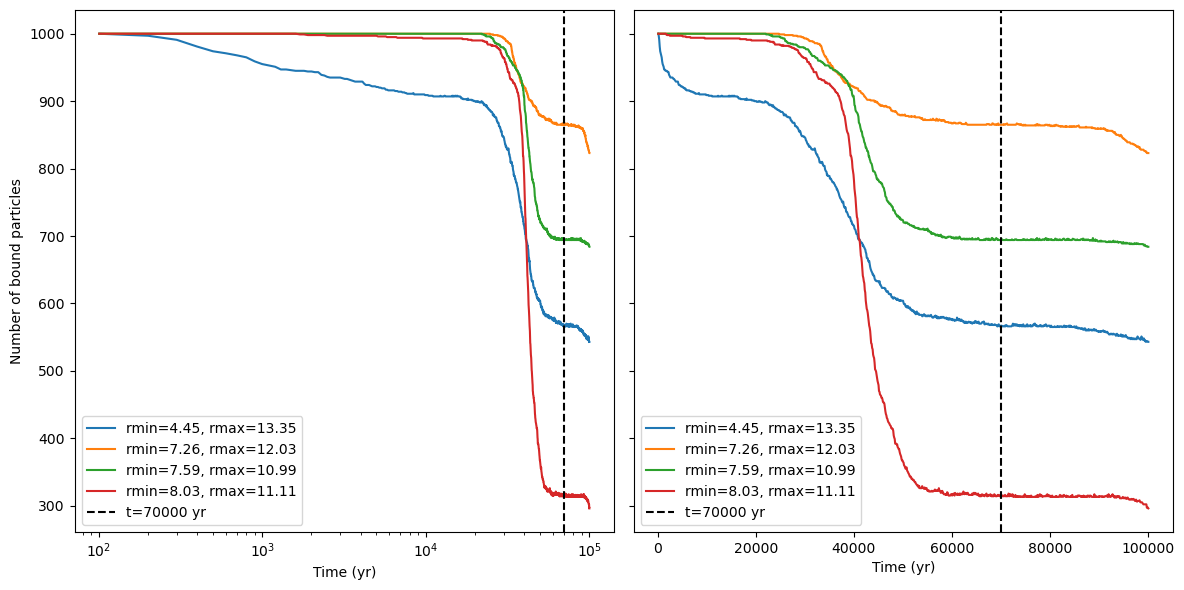

In [25]:
fig, (ax0,ax1) = plt.subplots(1,2,figsize=(12,6), sharey=True)

r_disks = []

for i in range(len(files)//2):
    nbound = np.load(files[i])
    times = np.load(files[i+len(files)//2])
    rmin = files[i].split('/')[-1].split('rmin')[1].split('_')[0]
    rmax = files[i].split('/')[-1].split('rmax')[1].split('.npy')[0]
    r_disks.append((rmin, rmax))
    print(rmin, rmax)

    ax0.plot(times, nbound, label=f'rmin={rmin}, rmax={rmax}')
    ax1.plot(times, nbound, label=f'rmin={rmin}, rmax={rmax}')

ax0.axvline(x=70000, color='k', linestyle='--', label='t=70000 yr')
ax1.axvline(x=70000, color='k', linestyle='--', label='t=70000 yr')
ax0.set_xscale('log')
# ax1.set_yscale('log')
ax0.legend()
ax1.legend()
ax0.set_xlabel('Time (yr)')
ax1.set_xlabel('Time (yr)')
ax0.set_ylabel('Number of bound particles')

plt.tight_layout()
plt.show()

In [26]:
70000 * 365
25530429 /365 #days

69946.3808219178

In [27]:
from amuse.io import read_set_from_file
from amuse.units import units
from amuse.lab import Particles, Particle

9.94270368028 1.64225718187
rmin=8.300446498405703, rmax=11.584960862145854
9.66008261928 1.21791358152
rmin=8.442169037767977, rmax=10.87799620080065
10.0476464863 1.65123412024
rmin=8.396412366018545, rmax=11.698880606504513


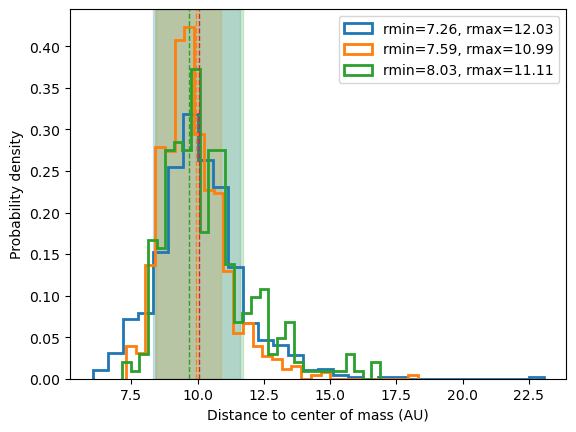

In [ ]:
#get matplotlib colors
clrs = plt.rcParams['axes.prop_cycle'].by_key()['color']
all_dists = []

for i in range(1,len(r_disks)):
    path = f'/home/ybadoux/AMUSE/hermite_hists/snapshot_25530429_{r_disks[i][0]}.hdf5'
    bodies = read_set_from_file(path)
    
    disk = bodies[bodies.name == 'disk']
    stars = Particles()
    stars.add_particle(bodies[bodies.name == 'primary_star'])
    stars.add_particle(bodies[bodies.name == 'secondary_star'])

    com = stars.center_of_mass()
    distances = []
    for body in disk:
        temp = body.position - com
        if temp.length().value_in(units.AU) < 25:
            # print(temp.length().value_in(units.AU))
            distances.append(temp.length().value_in(units.AU))
            all_dists.append(temp.length().value_in(units.AU))
    
    distances = np.array(distances)
    plt.hist(distances, bins=30, label=f'rmin={r_disks[i][0]}, rmax={r_disks[i][1]}', density=True, histtype='step', lw=2)
    plt.axvline(np.median(distances), linestyle='--', lw=1, color=clrs[i])
    print(np.median(distances),np.std(distances))
    print(f'rmin={np.median(distances) - np.std(distances)}, rmax={np.median(distances) + np.std(distances)}')
    plt.axvspan(np.median(distances) - np.std(distances), np.median(distances) + np.std(distances), alpha=0.2, color=clrs[i-1])



plt.xlabel('Distance to center of mass (AU)')
plt.ylabel('Probability density')

plt.legend()
plt.show()
    